In [1]:
import sys
from pathlib import Path

project_root = Path().absolute().parent
sys.path.insert(0, str(project_root))

import os
os.chdir(project_root)

In [2]:
import torch
import numpy as np
import yaml
from torch.utils.data import DataLoader

from src.data.pipeline import get_datasets
from src.models.transformer_model import StockTransformer
from src.simulation.engine import BacktestEngine
from src.simulation.metrics import compute_metrics
from src.utils.config import load_config

In [3]:
config = load_config()

# Use same project root as load_config() so path works regardless of cwd
from src.utils import config as _cfg
config_path = _cfg.PROJECT_ROOT / "configs" / "default_config.yaml"
with config_path.open("r", encoding="utf-8") as f:
    raw_cfg = yaml.safe_load(f)
sim = raw_cfg.get("simulation", {})

initial_capital = float(sim.get("initial_capital", 100_000))
position_size_pct = float(sim.get("position_size_pct", 1.0))
entry_threshold_pct = float(sim.get("entry_threshold_pct", 0.5))
exit_threshold_pct = float(sim.get("exit_threshold_pct", -0.5))
commission_pct = float(sim.get("commission_pct", 0.1))
risk_free_rate_annual = float(sim.get("risk_free_rate_annual", 0.03))

print("Simulation config:", initial_capital, position_size_pct, entry_threshold_pct, exit_threshold_pct, commission_pct)

Simulation config: 100000.0 0.3 0.5 -5.0 0.1


In [4]:
from src.data.pipeline import extract_dataset
from src.data.dataset import time_series_split
from src.utils.config import split_per_symbol

_, _, test_dataset, feature_columns = get_datasets(config)
print(f"Test samples: {len(test_dataset)}, features: {len(feature_columns)}")
print(f"Target: {config.data.target_column}, split: {config.data.split_mode}")

df_all, _ = extract_dataset(config)
_, _, test_df = time_series_split(
    df_all,
    train_split=config.data.train_split,
    val_split=config.data.val_split,
    test_split=config.data.test_split,
    per_symbol=split_per_symbol(config),
)

price_col = config.data.price_column
target_col = config.data.target_column
date_col = "date"
symbol_col = "symbol"

sort_cols = [symbol_col, date_col] if symbol_col in test_df.columns else [date_col]
test_df = test_df.sort_values(sort_cols).reset_index(drop=True)

if symbol_col in test_df.columns:
    print(f"Tickers in test set: {sorted(test_df[symbol_col].unique())}")
    print(f"Test rows: {len(test_df)}")
    print(f"Rows per ticker: {test_df.groupby(symbol_col).size().to_dict()}")

Test samples: 1854, features: 34
Target: log_return, split: per_symbol
Tickers in test set: ['AAPL', 'AMZN', 'BAC', 'COST', 'CVX', 'GOOGL', 'JNJ', 'JPM', 'KO', 'MA', 'MSFT', 'NFLX']
Test rows: 2574
Rows per ticker: {'AAPL': 215, 'AMZN': 201, 'BAC': 196, 'COST': 218, 'CVX': 218, 'GOOGL': 218, 'JNJ': 218, 'JPM': 218, 'KO': 218, 'MA': 218, 'MSFT': 218, 'NFLX': 218}


In [5]:
# Use project root + config checkpoint filename (set paths.checkpoint_file in config for correct model)
checkpoint_name = getattr(config.paths, "checkpoint_file", "best_model.pt")
checkpoint_path = _cfg.PROJECT_ROOT / config.paths.models_dir / checkpoint_name
if not checkpoint_path.exists():
    raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}. Train with 01_train_model.ipynb or set paths.checkpoint_file in config.")
import time
mtime = time.ctime(checkpoint_path.stat().st_mtime)
checkpoint = torch.load(checkpoint_path, map_location="cpu")
state_dict = checkpoint["model_state_dict"]
print(f"Loaded: {checkpoint_path.name} (modified {mtime})")
print(f"Checkpoint: epoch {checkpoint.get('epoch', '?') + 1}, val loss {checkpoint.get('score', '?'):.6f}")

# Ensure feature_columns is defined (from cell 3)
if 'feature_columns' not in globals():
    print("Warning: feature_columns not found, loading datasets...")
    _, _, _, feature_columns = get_datasets(config)

input_dim_checkpoint = state_dict["input_projection.weight"].shape[1]
input_dim_current = len(feature_columns)
d_model = state_dict["input_projection.weight"].shape[0]
n_layers = len([k for k in state_dict if "encoder.layers" in k and "self_attention.w_q.weight" in k])
n_heads = config.model.n_heads
d_ff = state_dict["encoder.layers.0.feed_forward.linear1.weight"].shape[0]

if input_dim_checkpoint != input_dim_current:
    model = StockTransformer(
        input_dim=input_dim_current,
        d_model=d_model,
        n_heads=n_heads,
        n_layers=n_layers,
        d_ff=d_ff,
        dropout=config.model.dropout,
        activation=config.model.activation,
        prediction_horizon=config.data.prediction_horizon,
    )
    model_dict = model.state_dict()
    compatible_dict = {k: v for k, v in state_dict.items()
                      if k in model_dict and model_dict[k].shape == v.shape}
    model_dict.update(compatible_dict)
    model.load_state_dict(model_dict, strict=False)
    print(f"Loaded {len(compatible_dict)}/{len(state_dict)} params (input_dim mismatch: using current features)")
else:
    model = StockTransformer(
        input_dim=input_dim_checkpoint,
        d_model=d_model,
        n_heads=n_heads,
        n_layers=n_layers,
        d_ff=d_ff,
        dropout=config.model.dropout,
        activation=config.model.activation,
        prediction_horizon=config.data.prediction_horizon,
    )
    model.load_state_dict(state_dict)
    print("Model loaded.")
model.eval()

Loaded: best_model_base.pt (modified Thu May 28 14:09:11 2026)
Checkpoint: epoch 18, val loss 0.000110
Model loaded.


StockTransformer(
  (input_projection): Linear(in_features=34, out_features=256, bias=True)
  (pos_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerEncoderLayer(
        (self_attention): MultiHeadAttention(
          (w_q): Linear(in_features=256, out_features=256, bias=True)
          (w_k): Linear(in_features=256, out_features=256, bias=True)
          (w_v): Linear(in_features=256, out_features=256, bias=True)
          (w_o): Linear(in_features=256, out_features=256, bias=True)
          (attention): ScaledDotProductAttention(
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (feed_forward): FeedForward(
          (linear1): Linear(in_features=256, out_features=1024, bias=True)
          (linear2): Linear(in_features=1024, out_features=256, bias=True)
          (dropout): Dropout(p=

In [6]:
import pandas as pd
from src.data.dataset import create_sequences

# Smart long-only strategy: fixed, opinionated trading logic using EMA-smoothed
# predictions, volatility-normalized z-scores, confirmation, regime filtering,
# trailing stop, take profit and time stop. No manual percentile tuning.
strategy_name = "smart_long_only"
min_trading_days = 80

ctx = config.data.context_length
print(f"Trading mode: {strategy_name}")
print("Running per-ticker backtests...")

engine = BacktestEngine(
    initial_capital=initial_capital,
    position_size_pct=position_size_pct,
    entry_threshold_pct=entry_threshold_pct,
    exit_threshold_pct=exit_threshold_pct,
    commission_pct=commission_pct,
)

per_ticker_results = {}
summary_rows = []

for ticker, group in test_df.groupby(symbol_col):
    group = group.sort_values(date_col).reset_index(drop=True)
    if len(group) < ctx + config.data.prediction_horizon + 1:
        print(f"Skipping {ticker}: not enough rows ({len(group)})")
        continue

    stacked = np.column_stack([
        group[feature_columns].values,
        group[target_col].values.reshape(-1, 1),
    ])
    seq_X, seq_y = create_sequences(stacked, ctx, config.data.prediction_horizon)
    if len(seq_X) == 0:
        print(f"Skipping {ticker}: no sequences")
        continue

    X = seq_X[:, :, :-1]
    if config.data.prediction_horizon > 1:
        actual_returns_ticker = seq_y[:, :, -1].reshape(len(seq_X), -1)[:, -1]
    else:
        actual_returns_ticker = seq_y[:, -1, -1]

    prices_ticker = group[price_col].values[ctx : ctx + len(seq_X)]
    dates_ticker = group[date_col].values[ctx : ctx + len(seq_X)]

    pred_batches = []
    model.eval()
    with torch.no_grad():
        for start in range(0, len(X), config.training.batch_size):
            batch_x = torch.FloatTensor(X[start : start + config.training.batch_size])
            pred = model(batch_x)
            pred_batches.append(pred.detach().cpu())
    predicted_returns_ticker = torch.cat(pred_batches).numpy().reshape(-1)

    if len(prices_ticker) < min_trading_days:
        print(f"Skipping {ticker}: only {len(prices_ticker)} test trading days")
        continue

    result_ticker = engine.run_smart_long_only(
        prices=prices_ticker,
        predicted_returns=predicted_returns_ticker,
        dates=dates_ticker,
    )

    metrics_ticker = compute_metrics(
        result_ticker,
        initial_capital=initial_capital,
        risk_free_rate_annual=risk_free_rate_annual,
        prices=prices_ticker,
    )

    directional_accuracy = float(
        np.mean(np.sign(predicted_returns_ticker) == np.sign(actual_returns_ticker))
    )
    n_buy_trades = sum(1 for t in result_ticker.trades if t.side == "buy")

    per_ticker_results[ticker] = {
        "result": result_ticker,
        "metrics": metrics_ticker,
        "prices": prices_ticker,
        "dates": dates_ticker,
        "predicted_returns": predicted_returns_ticker,
        "actual_returns": actual_returns_ticker,
        "entry_thr_curve": result_ticker.entry_thresholds,
        "exit_thr_curve": result_ticker.exit_thresholds,
    }

    summary_rows.append({
        "ticker": ticker,
        "days": len(prices_ticker),
        "strategy": strategy_name,
        "buy_trade_pct": 100 * n_buy_trades / len(prices_ticker),
        "directional_accuracy_pct": 100 * directional_accuracy,
        "strategy_return_pct": metrics_ticker.total_return_pct,
        "buy_hold_return_pct": metrics_ticker.buy_and_hold_return_pct,
        "excess_vs_bh_pct": metrics_ticker.excess_return_vs_bh_pct,
        "max_drawdown_pct": metrics_ticker.max_drawdown_pct,
        "sharpe": metrics_ticker.sharpe_ratio_annual,
        "trades": metrics_ticker.num_trades,
    })

summary_df = pd.DataFrame(summary_rows).sort_values("excess_vs_bh_pct", ascending=False)

print("=" * 90)
print("PER-TICKER BACKTEST SUMMARY")
print("=" * 90)
display(summary_df.style.format({
    "buy_trade_pct": "{:.1f}%",
    "directional_accuracy_pct": "{:.1f}%",
    "strategy_return_pct": "{:.2f}%",
    "buy_hold_return_pct": "{:.2f}%",
    "excess_vs_bh_pct": "{:+.2f}%",
    "max_drawdown_pct": "{:.2f}%",
    "sharpe": "{:.3f}",
}))

print("\nAggregate:")
print(f"Tickers tested:              {len(summary_df)}")
print(f"Mean strategy return:        {summary_df['strategy_return_pct'].mean():.2f}%")
print(f"Mean buy & hold return:      {summary_df['buy_hold_return_pct'].mean():.2f}%")
print(f"Mean excess vs B&H:          {summary_df['excess_vs_bh_pct'].mean():+.2f}%")
print(f"Median excess vs B&H:        {summary_df['excess_vs_bh_pct'].median():+.2f}%")
print(f"Tickers beating B&H:         {(summary_df['excess_vs_bh_pct'] > 0).sum()} / {len(summary_df)}")
print(f"Mean directional accuracy:   {summary_df['directional_accuracy_pct'].mean():.2f}%")
print(f"Mean trades per ticker:      {summary_df['trades'].mean():.1f}")
print(f"Mean buy trade frequency:    {summary_df['buy_trade_pct'].mean():.1f}%")

# Keep a representative ticker for plotting in the next cell.
plot_ticker = summary_df.iloc[0]["ticker"] if len(summary_df) else None
print(f"\nDefault plot_ticker = {plot_ticker} (best excess vs B&H)")

Trading mode: smart_long_only
Running per-ticker backtests...
PER-TICKER BACKTEST SUMMARY


,ticker,days,strategy,buy_trade_pct,directional_accuracy_pct,strategy_return_pct,buy_hold_return_pct,excess_vs_bh_pct,max_drawdown_pct,sharpe,trades
4,CVX,158,smart_long_only,1.3%,48.7%,-4.22%,-32.76%,+28.54%,4.22%,-3.510,4
7,JPM,158,smart_long_only,1.3%,48.1%,-1.41%,-29.23%,+27.82%,1.69%,-1.558,4
8,KO,158,smart_long_only,2.5%,47.5%,4.07%,-16.27%,+20.34%,1.98%,0.732,8
9,MA,158,smart_long_only,2.5%,53.2%,0.75%,-1.10%,+1.85%,2.44%,-0.306,8
5,GOOGL,158,smart_long_only,1.3%,54.4%,-1.89%,-3.47%,+1.58%,2.47%,-1.424,4
6,JNJ,158,smart_long_only,2.5%,48.7%,0.01%,-0.08%,+0.09%,2.53%,-0.770,8
3,COST,158,smart_long_only,1.9%,51.3%,3.38%,11.12%,-7.74%,1.85%,0.799,6
1,AMZN,141,smart_long_only,0.7%,41.1%,1.15%,13.39%,-12.24%,0.77%,-0.329,2
10,MSFT,158,smart_long_only,1.9%,55.7%,-2.29%,12.71%,-15.00%,4.35%,-1.227,6
2,BAC,136,smart_long_only,0.7%,53.7%,-0.32%,15.90%,-16.22%,1.67%,-1.122,2



Aggregate:
Tickers tested:              12
Mean strategy return:        0.72%
Mean buy & hold return:      3.69%
Mean excess vs B&H:          -2.97%
Median excess vs B&H:        -3.83%
Tickers beating B&H:         6 / 12
Mean directional accuracy:   50.60%
Mean trades per ticker:      5.2
Mean buy trade frequency:    1.7%

Default plot_ticker = CVX (best excess vs B&H)


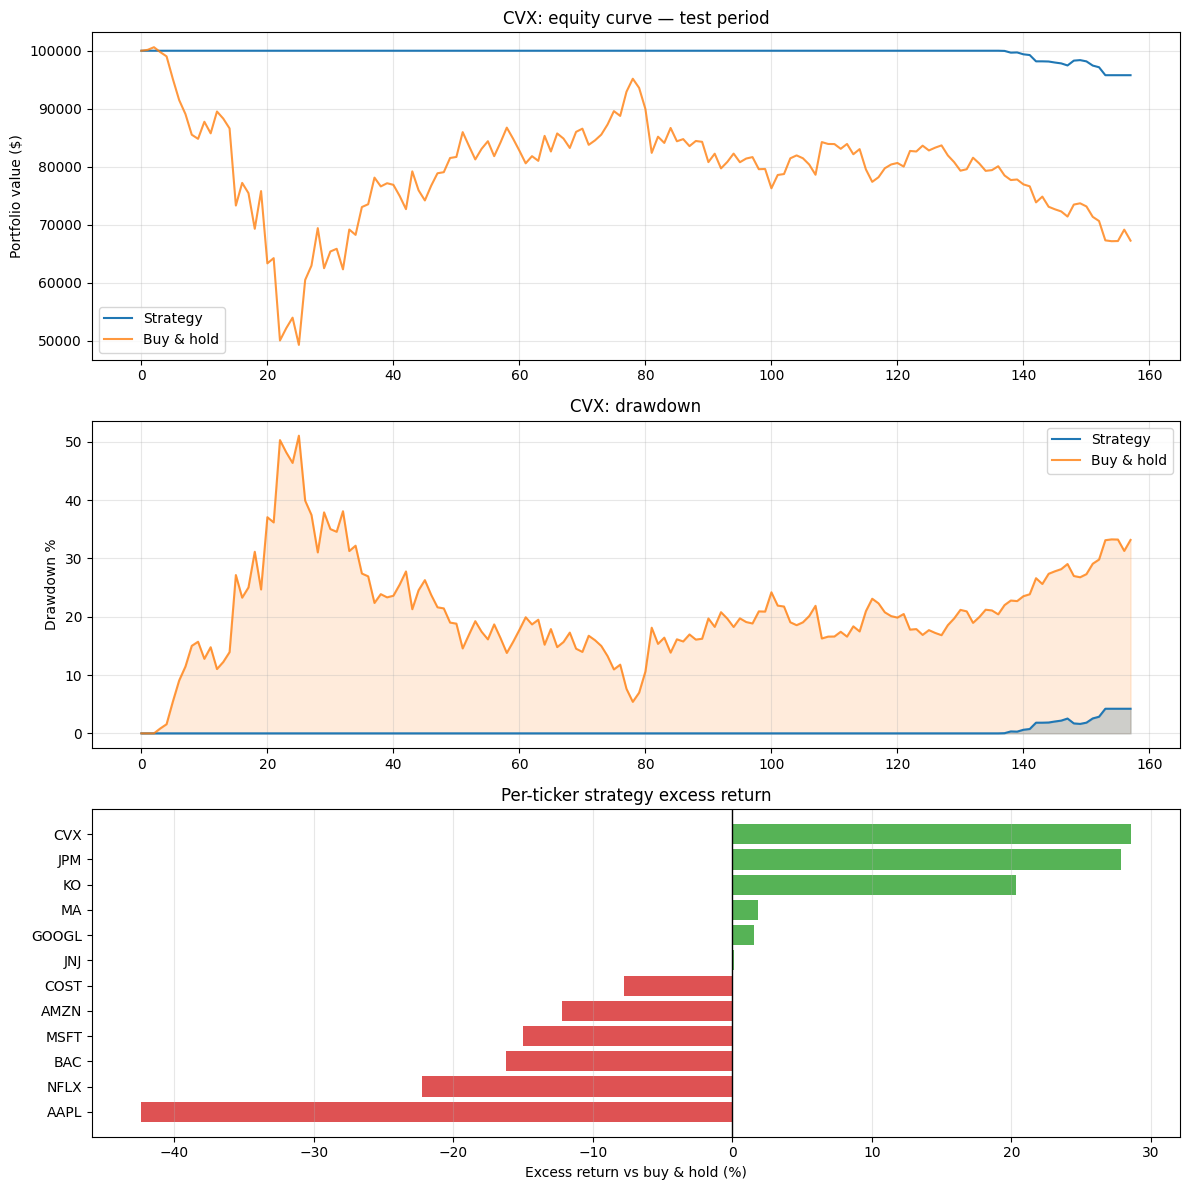

In [7]:
import matplotlib.pyplot as plt

if plot_ticker is None:
    raise ValueError("No ticker results available to plot.")

# Change this manually if you want another ticker, e.g. plot_ticker = "AAPL"
r = per_ticker_results[plot_ticker]
result = r["result"]
prices = r["prices"]

bh_shares = initial_capital / prices[0]
bh_equity = bh_shares * prices

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=False)

def drawdown_pct(equity):
    peak = np.maximum.accumulate(equity)
    safe = np.where(peak <= 0, np.nan, peak)
    return np.nan_to_num(100 * (peak - equity) / safe, nan=0.0)

ax1 = axes[0]
ax1.plot(result.equity_curve, label="Strategy", linewidth=1.5)
ax1.plot(bh_equity, label="Buy & hold", alpha=0.8, linewidth=1.5)
ax1.set_ylabel("Portfolio value ($)")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_title(f"{plot_ticker}: equity curve — test period")

ax2 = axes[1]
x = np.arange(len(result.equity_curve))
strategy_dd = drawdown_pct(result.equity_curve)
bh_dd = drawdown_pct(bh_equity)
ax2.plot(x, strategy_dd, label="Strategy", color="C0")
ax2.fill_between(x, strategy_dd, 0, alpha=0.25, color="C0")
ax2.plot(x, bh_dd, label="Buy & hold", color="C1", alpha=0.8)
ax2.fill_between(x, bh_dd, 0, alpha=0.15, color="C1")
ax2.set_ylabel("Drawdown %")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_title(f"{plot_ticker}: drawdown")

ax3 = axes[2]
plot_df = summary_df.sort_values("excess_vs_bh_pct", ascending=True)
colors = np.where(plot_df["excess_vs_bh_pct"] > 0, "C2", "C3")
ax3.barh(plot_df["ticker"], plot_df["excess_vs_bh_pct"], color=colors, alpha=0.8)
ax3.axvline(0, color="black", linewidth=1)
ax3.set_xlabel("Excess return vs buy & hold (%)")
ax3.set_title("Per-ticker strategy excess return")
ax3.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.show()